# Driving force calculation

Text(0, 0.5, 'Liquid Driving Force [J / mol]')

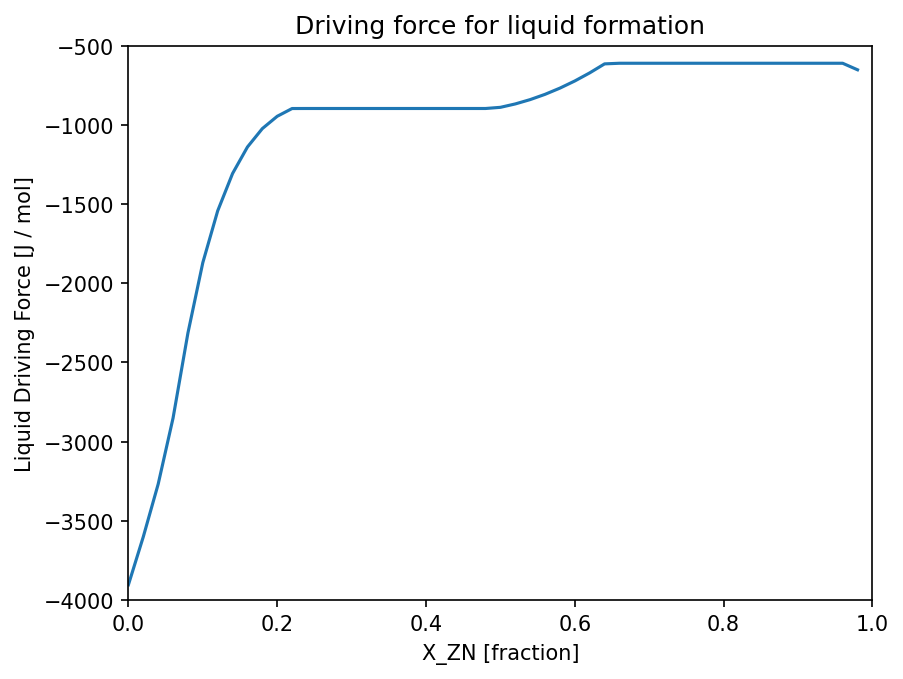

In [1]:
from pycalphad import Workspace, variables as v
from pycalphad.property_framework.metaproperties import DormantPhase
import matplotlib.pyplot as plt

db = 'databases/alzn_mey.tdb'
components = ['AL', 'ZN']
phases = ['FCC_A1', 'HCP_A3', 'LIQUID']

conditions3 = {v.X('ZN'):(0,1,0.02), v.T: 600, v.P:101325, v.N: 1}
wks3 = Workspace(db, components, phases, conditions3)
metastable_liq_wks = wks3.copy()
metastable_liq_wks.phases = ['LIQUID']
liq_driving_force = DormantPhase('LIQUID', metastable_liq_wks).driving_force
liq_driving_force.display_name = 'Liquid Driving Force'

fig = plt.figure(dpi=150)
ax = fig.add_subplot()
ax.plot(wks3.get(v.X('ZN')), wks3.get(liq_driving_force))
ax.set_title("Driving force for liquid formation")
ax.set_xlim([0,1])
ax.set_ylim([-4000,-500])
ax.set_xlabel(f"{v.X('ZN').display_name} [{v.X('ZN').display_units}]")
ax.set_ylabel(f"{liq_driving_force.display_name} [{liq_driving_force.display_units}]")

# Calculate T0 (t-zero) as a function of composition

The T0 (t-zero) temperature is a thermodynamic condition in which two specified phases have the same value of the Gibbs energy. Below T0, a so-called "massive" phase transition is thermodynamically favored to occur, without a barrier to diffusion.

Text(0, 0.5, 'T0(FCC_A1,HCP_A3) [kelvin]')

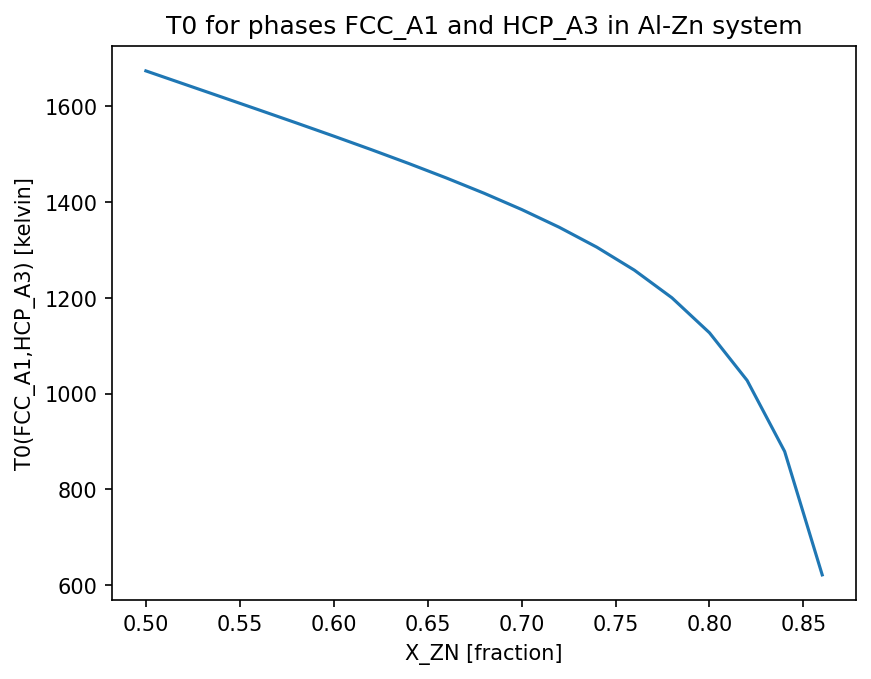

In [2]:
from pycalphad.property_framework.tzero import T0

# For T0, conditions must be one-dimensional (step calculation)
conditions4 = {v.X('ZN'): (0,1,0.02), v.T: 300, v.P:101325, v.N: 1}
wks4 = Workspace(db, components, phases, conditions4)
tzero = T0('FCC_A1', 'HCP_A3', wks4)
tzero.maximum_value = 1700 # set temperature limit

fig = plt.figure(dpi=150)
ax = fig.add_subplot()
ax.plot(wks4.get(v.X('ZN')), wks4.get(tzero))
ax.set_title("T0 for phases FCC_A1 and HCP_A3 in Al-Zn system")
ax.set_xlabel(f"{v.X('ZN').display_name} [{v.X('ZN').display_units}]")
ax.set_ylabel(f"{tzero} [{tzero.display_units}]")